<a href="https://colab.research.google.com/github/AdryanaCorazonDeDragon/alurachallenge3/blob/main/TelecomX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ANÁLISIS DE EVASIÓN DE CLIENTES - TELECOM X (PARTE II)

---



## Paquetería de importación.

In [637]:
import requests
import pandas as pd

In [638]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [639]:
import plotly.express as px

## Extración de datos

In [640]:
# Estración de datos por url.
url = 'https://raw.githubusercontent.com/AdryanaCorazonDeDragon/alurachallenge3/refs/heads/main/TelecomX_Primera_Parte.json'
response = requests.get(url)

data = response.json()

In [641]:
# Datos en Data Frame.
df = pd.DataFrame(data)
df = pd.json_normalize(data)

df.head()

,customer_id,churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,...,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges_monthly,account_charges_total,account_charges_diary
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


## Exploración de datos.

In [642]:
# Cantidad de filas y columnas
df.shape

(7043, 22)

In [643]:
# Columnas del Data Frame.
df.columns

Index(['customer_id', 'churn', 'customer_gender', 'customer_seniorcitizen',
       'customer_partner', 'customer_dependents', 'customer_tenure',
       'phone_phoneservice', 'phone_multiplelines', 'internet_internetservice',
       'internet_onlinesecurity', 'internet_onlinebackup',
       'internet_deviceprotection', 'internet_techsupport',
       'internet_streamingtv', 'internet_streamingmovies', 'account_contract',
       'account_paperlessbilling', 'account_paymentmethod',
       'account_charges_monthly', 'account_charges_total',
       'account_charges_diary'],
      dtype='object')

In [644]:
# Información general del Data Frame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                7043 non-null   object 
 1   churn                      7043 non-null   object 
 2   customer_gender            7043 non-null   object 
 3   customer_seniorcitizen     7043 non-null   int64  
 4   customer_partner           7043 non-null   object 
 5   customer_dependents        7043 non-null   object 
 6   customer_tenure            7043 non-null   int64  
 7   phone_phoneservice         7043 non-null   object 
 8   phone_multiplelines        7043 non-null   object 
 9   internet_internetservice   7043 non-null   object 
 10  internet_onlinesecurity    7043 non-null   object 
 11  internet_onlinebackup      7043 non-null   object 
 12  internet_deviceprotection  7043 non-null   object 
 13  internet_techsupport       7043 non-null   objec

In [645]:
# Verificación de valores únicos en cada columna
print(f'{"*"*12}  VALORES ÚNICOS SEGUN LA COLUMNA   {"*"* 12} \n{"-" * 60}')
for column in df.columns:
    unique_values = df[column].unique()
    print(f'Valores únicos en la columna "{column.lower()}": {len(unique_values)}')
    if len(unique_values) < 50:
      print(unique_values)
    print('-' * 60)

************  VALORES ÚNICOS SEGUN LA COLUMNA   ************ 
------------------------------------------------------------
Valores únicos en la columna "customer_id": 7043
------------------------------------------------------------
Valores únicos en la columna "churn": 2
['No' 'Yes']
------------------------------------------------------------
Valores únicos en la columna "customer_gender": 2
['Female' 'Male']
------------------------------------------------------------
Valores únicos en la columna "customer_seniorcitizen": 2
[0 1]
------------------------------------------------------------
Valores únicos en la columna "customer_partner": 2
['Yes' 'No']
------------------------------------------------------------
Valores únicos en la columna "customer_dependents": 2
['Yes' 'No']
------------------------------------------------------------
Valores únicos en la columna "customer_tenure": 73
------------------------------------------------------------
Valores únicos en la columna "phone

In [646]:
# Prueba de datos nulos
df.isnull().sum()

,0
customer_id,0
churn,0
customer_gender,0
customer_seniorcitizen,0
customer_partner,0
customer_dependents,0
customer_tenure,0
phone_phoneservice,0
phone_multiplelines,0
internet_internetservice,0


In [647]:
# Copia de trabajo.
datos = df.copy()

## Tratamiento de datos.

### Eliminación de columnas irrelevantes.

Eliminación de columnas sin valor predictivo, redudantes, y con posibles causas de fuga.

In [648]:
# Eliminación de columna customer_id
datos.drop('customer_id', axis=1, inplace=True)
datos.columns

Index(['churn', 'customer_gender', 'customer_seniorcitizen',
       'customer_partner', 'customer_dependents', 'customer_tenure',
       'phone_phoneservice', 'phone_multiplelines', 'internet_internetservice',
       'internet_onlinesecurity', 'internet_onlinebackup',
       'internet_deviceprotection', 'internet_techsupport',
       'internet_streamingtv', 'internet_streamingmovies', 'account_contract',
       'account_paperlessbilling', 'account_paymentmethod',
       'account_charges_monthly', 'account_charges_total',
       'account_charges_diary'],
      dtype='object')

### Estandarización de datos.

In [649]:
# Tratamiento de las palabras del documento.
datos['account_paymentmethod'] = datos['account_paymentmethod'].str.replace('(automatic)', 'automatic').str.replace(' ','_').str.lower()
datos['account_paymentmethod'].unique()

array(['mailed_check', 'electronic_check', 'credit_card_automatic',
       'bank_transfer_automatic'], dtype=object)

In [650]:
datos['account_contract'] = datos['account_contract'].str.replace(' ','_').str.lower()
datos['account_contract'].unique()

array(['one_year', 'month-to-month', 'two_year'], dtype=object)

In [651]:
datos['internet_internetservice'] = datos['internet_internetservice'].str.replace(' ','_').str.lower()
datos['internet_internetservice'].unique()

array(['dsl', 'fiber_optic', 'no'], dtype=object)

### Agrupación de datos.

In [652]:
# Copia de para datos agrupados.
datos_agrupados = datos.copy()

In [653]:
# Columnas de internet.
columnas_internet = ['internet_onlinesecurity', 'internet_onlinebackup',
                     'internet_deviceprotection', 'internet_techsupport',
                     'internet_streamingtv', 'internet_streamingmovies']

In [654]:
# Columnas estaderizadas y agrupadas.
for columna in columnas_internet:
    datos_agrupados[columna] = datos_agrupados[columna].apply(lambda x: True if x == 'Yes' else False)

In [655]:
# Estaderización y agrupación de los datos de la columna 'phone_multiplelines'
datos_agrupados['phone_multiplelines'] = datos_agrupados['phone_multiplelines'].apply(lambda x: True if x == 'Yes' else False)

In [656]:
datos_agrupados.head()

,churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,internet_onlinesecurity,...,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges_monthly,account_charges_total,account_charges_diary
0,No,Female,0,Yes,Yes,9,Yes,False,dsl,False,...,False,True,True,False,one_year,Yes,mailed_check,65.6,593.30,2.186667
1,No,Male,0,No,No,9,Yes,True,dsl,False,...,False,False,False,True,month-to-month,No,mailed_check,59.9,542.40,1.996667
2,Yes,Male,0,No,No,4,Yes,False,fiber_optic,False,...,True,False,False,False,month-to-month,Yes,electronic_check,73.9,280.85,2.463333
3,Yes,Male,1,Yes,No,13,Yes,False,fiber_optic,False,...,True,False,True,True,month-to-month,Yes,electronic_check,98.0,1237.85,3.266667
4,Yes,Female,1,Yes,No,3,Yes,False,fiber_optic,False,...,False,True,True,False,month-to-month,Yes,mailed_check,83.9,267.40,2.796667


### Tratamiento de datos nulos.

Existen 11 filas nulas al ser un número pequeño de datos optamos por eliminarlos, en caso de ser una cantidad considerabale los remplazariamos por 0.

In [657]:
# Elimina filas con valores nulos en las columnas especificadas
datos_agrupados = datos_agrupados.dropna(subset=['account_charges_total'])

In [658]:
# Verifica valores nulos en las dos columnas
print(datos_agrupados['account_charges_total'].isnull().sum())

0


## Enconding (sin dummy trap)

### Variables caracteristicas y númericas.

In [659]:
# Variables caracteristicas.
columnas_categorias = ['churn', 'customer_gender', 'customer_seniorcitizen',
       'customer_partner', 'customer_dependents',
       'phone_phoneservice', 'phone_multiplelines', 'internet_internetservice',
       'internet_onlinesecurity', 'internet_onlinebackup',
       'internet_deviceprotection', 'internet_techsupport',
       'internet_streamingtv', 'internet_streamingmovies', 'account_contract',
       'account_paperlessbilling', 'account_paymentmethod',
       ]

### Datos Enconding

In [660]:
datos_enconding = pd.get_dummies(datos_agrupados, columns=columnas_categorias, drop_first=True)
datos_enconding.head()

,customer_tenure,account_charges_monthly,account_charges_total,account_charges_diary,churn_Yes,customer_gender_Male,customer_seniorcitizen_1,customer_partner_Yes,customer_dependents_Yes,phone_phoneservice_Yes,...,internet_deviceprotection_True,internet_techsupport_True,internet_streamingtv_True,internet_streamingmovies_True,account_contract_one_year,account_contract_two_year,account_paperlessbilling_Yes,account_paymentmethod_credit_card_automatic,account_paymentmethod_electronic_check,account_paymentmethod_mailed_check
0,9,65.6,593.30,2.186667,False,False,False,True,True,True,...,False,True,True,False,True,False,True,False,False,True
1,9,59.9,542.40,1.996667,False,True,False,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,4,73.9,280.85,2.463333,True,True,False,False,False,True,...,True,False,False,False,False,False,True,False,True,False
3,13,98.0,1237.85,3.266667,True,True,True,True,False,True,...,True,False,True,True,False,False,True,False,True,False
4,3,83.9,267.40,2.796667,True,False,True,True,False,True,...,False,True,True,False,False,False,True,False,False,True


In [661]:
# Estandarización de los nombres de columnas.
datos_enconding.columns = datos_enconding.columns.str.replace('1', 'Yes').str.replace('True','Yes').str.lower()

In [662]:
datos_enconding.columns

Index(['customer_tenure', 'account_charges_monthly', 'account_charges_total',
       'account_charges_diary', 'churn_yes', 'customer_gender_male',
       'customer_seniorcitizen_yes', 'customer_partner_yes',
       'customer_dependents_yes', 'phone_phoneservice_yes',
       'phone_multiplelines_yes', 'internet_internetservice_fiber_optic',
       'internet_internetservice_no', 'internet_onlinesecurity_yes',
       'internet_onlinebackup_yes', 'internet_deviceprotection_yes',
       'internet_techsupport_yes', 'internet_streamingtv_yes',
       'internet_streamingmovies_yes', 'account_contract_one_year',
       'account_contract_two_year', 'account_paperlessbilling_yes',
       'account_paymentmethod_credit_card_automatic',
       'account_paymentmethod_electronic_check',
       'account_paymentmethod_mailed_check'],
      dtype='object')

### Verificación de la información.

In [663]:
datos_enconding.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   customer_tenure                              7032 non-null   int64  
 1   account_charges_monthly                      7032 non-null   float64
 2   account_charges_total                        7032 non-null   float64
 3   account_charges_diary                        7032 non-null   float64
 4   churn_yes                                    7032 non-null   bool   
 5   customer_gender_male                         7032 non-null   bool   
 6   customer_seniorcitizen_yes                   7032 non-null   bool   
 7   customer_partner_yes                         7032 non-null   bool   
 8   customer_dependents_yes                      7032 non-null   bool   
 9   phone_phoneservice_yes                       7032 non-null   bool   
 10  phone

## Verificación de la Proporción de Cancelación. (CHURN)

In [664]:
datos_enconding['churn_yes'].value_counts()

,count
churn_yes,
False,5163
True,1869


In [665]:
ax = px.histogram(datos_enconding, x='churn_yes', color='churn_yes', title='Distribución de Churn',
                  color_discrete_map={True: 'green', False: 'red'}, text_auto=True,labels={'churn_yes': 'CHURN'})
ax.update_layout(showlegend=False)
ax.update_layout(title={'x':0.5, 'y':0.9, 'font':{'size': 20, 'family': 'sans-serif'}}, width= 900, height=500)
ax.update_xaxes(tickvals=[False, True],ticktext=['No', 'Yes'])
ax.update_yaxes(title_text='CLIENTES')

ax.show()

## Normalización de datos.

In [666]:
from sklearn.preprocessing import MinMaxScaler

In [667]:
# Columnas numéricas
columnas_numericas = datos_enconding.select_dtypes(include=['int64', 'float64']).columns
columnas_numericas

Index(['customer_tenure', 'account_charges_monthly', 'account_charges_total',
       'account_charges_diary'],
      dtype='object')

In [668]:
# Datos Normalizados
scaler = MinMaxScaler()
datos_enconding[columnas_numericas] = scaler.fit_transform(datos_enconding[columnas_numericas])

datos_enconding.head()

,customer_tenure,account_charges_monthly,account_charges_total,account_charges_diary,churn_yes,customer_gender_male,customer_seniorcitizen_yes,customer_partner_yes,customer_dependents_yes,phone_phoneservice_yes,...,internet_deviceprotection_yes,internet_techsupport_yes,internet_streamingtv_yes,internet_streamingmovies_yes,account_contract_one_year,account_contract_two_year,account_paperlessbilling_yes,account_paymentmethod_credit_card_automatic,account_paymentmethod_electronic_check,account_paymentmethod_mailed_check
0,0.112676,0.471144,0.066294,0.471144,False,False,False,True,True,True,...,False,True,True,False,True,False,True,False,False,True
1,0.112676,0.414428,0.060420,0.414428,False,True,False,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,0.042254,0.553731,0.030239,0.553731,True,True,False,False,False,True,...,True,False,False,False,False,False,True,False,True,False
3,0.169014,0.793532,0.140670,0.793532,True,True,True,True,False,True,...,True,False,True,True,False,False,True,False,True,False
4,0.028169,0.653234,0.028687,0.653234,True,False,True,True,False,True,...,False,True,True,False,False,False,True,False,False,True


## Análisis de Correlación.

### Correlación con todas las variables.

In [669]:
# Correlación de las variables.
correlacion = datos_enconding.corr()
correlacion

,customer_tenure,account_charges_monthly,account_charges_total,account_charges_diary,churn_yes,customer_gender_male,customer_seniorcitizen_yes,customer_partner_yes,customer_dependents_yes,phone_phoneservice_yes,...,internet_deviceprotection_yes,internet_techsupport_yes,internet_streamingtv_yes,internet_streamingmovies_yes,account_contract_one_year,account_contract_two_year,account_paperlessbilling_yes,account_paymentmethod_credit_card_automatic,account_paymentmethod_electronic_check,account_paymentmethod_mailed_check
customer_tenure,1.000000,0.246862,0.825880,0.246862,-0.354049,0.005285,0.015683,0.381912,0.163386,0.007877,...,0.361520,0.325288,0.280264,0.285402,0.202338,0.563801,0.004823,0.232800,-0.210197,-0.232181
account_charges_monthly,0.246862,1.000000,0.651065,1.000000,0.192858,-0.013779,0.219874,0.097825,-0.112343,0.248033,...,0.482607,0.338301,0.629668,0.627235,0.004810,-0.073256,0.351930,0.030055,0.271117,-0.376568
account_charges_total,0.825880,0.651065,1.000000,0.651065,-0.199484,0.000048,0.102411,0.319072,0.064653,0.113008,...,0.522881,0.432868,0.515709,0.519867,0.170569,0.358036,0.157830,0.182663,-0.060436,-0.294708
account_charges_diary,0.246862,1.000000,0.651065,1.000000,0.192858,-0.013779,0.219874,0.097825,-0.112343,0.248033,...,0.482607,0.338301,0.629668,0.627235,0.004810,-0.073256,0.351930,0.030055,0.271117,-0.376568
churn_yes,-0.354049,0.192858,-0.199484,0.192858,1.000000,-0.008545,0.150541,-0.149982,-0.163128,0.011691,...,-0.066193,-0.164716,0.063254,0.060860,-0.178225,-0.301552,0.191454,-0.134687,0.301455,-0.090773
customer_gender_male,0.005285,-0.013779,0.000048,-0.013779,-0.008545,1.000000,-0.001819,-0.001379,0.010349,-0.007515,...,-0.000807,-0.008507,-0.007124,-0.010105,0.007755,-0.003603,-0.011902,0.001632,0.000844,0.013199
customer_seniorcitizen_yes,0.015683,0.219874,0.102411,0.219874,0.150541,-0.001819,1.000000,0.016957,-0.210550,0.008392,...,0.059514,-0.060577,0.105445,0.119842,-0.046491,-0.116205,0.156258,-0.024359,0.171322,-0.152987
customer_partner_yes,0.381912,0.097825,0.319072,0.097825,-0.149982,-0.001379,0.016957,1.000000,0.452269,0.018397,...,0.153556,0.120206,0.124483,0.118108,0.083067,0.247334,-0.013957,0.082327,-0.083207,-0.096948
customer_dependents_yes,0.163386,-0.112343,0.064653,-0.112343,-0.163128,0.010349,-0.210550,0.452269,1.000000,-0.001078,...,0.013900,0.063053,-0.016499,-0.038375,0.069222,0.201699,-0.110131,0.061134,-0.149274,0.056448
phone_phoneservice_yes,0.007877,0.248033,0.113008,0.248033,0.011691,-0.007515,0.008392,0.018397,-0.001078,1.000000,...,-0.070076,-0.095138,-0.021383,-0.033477,-0.003142,0.004442,0.016696,-0.006916,0.002747,-0.004463


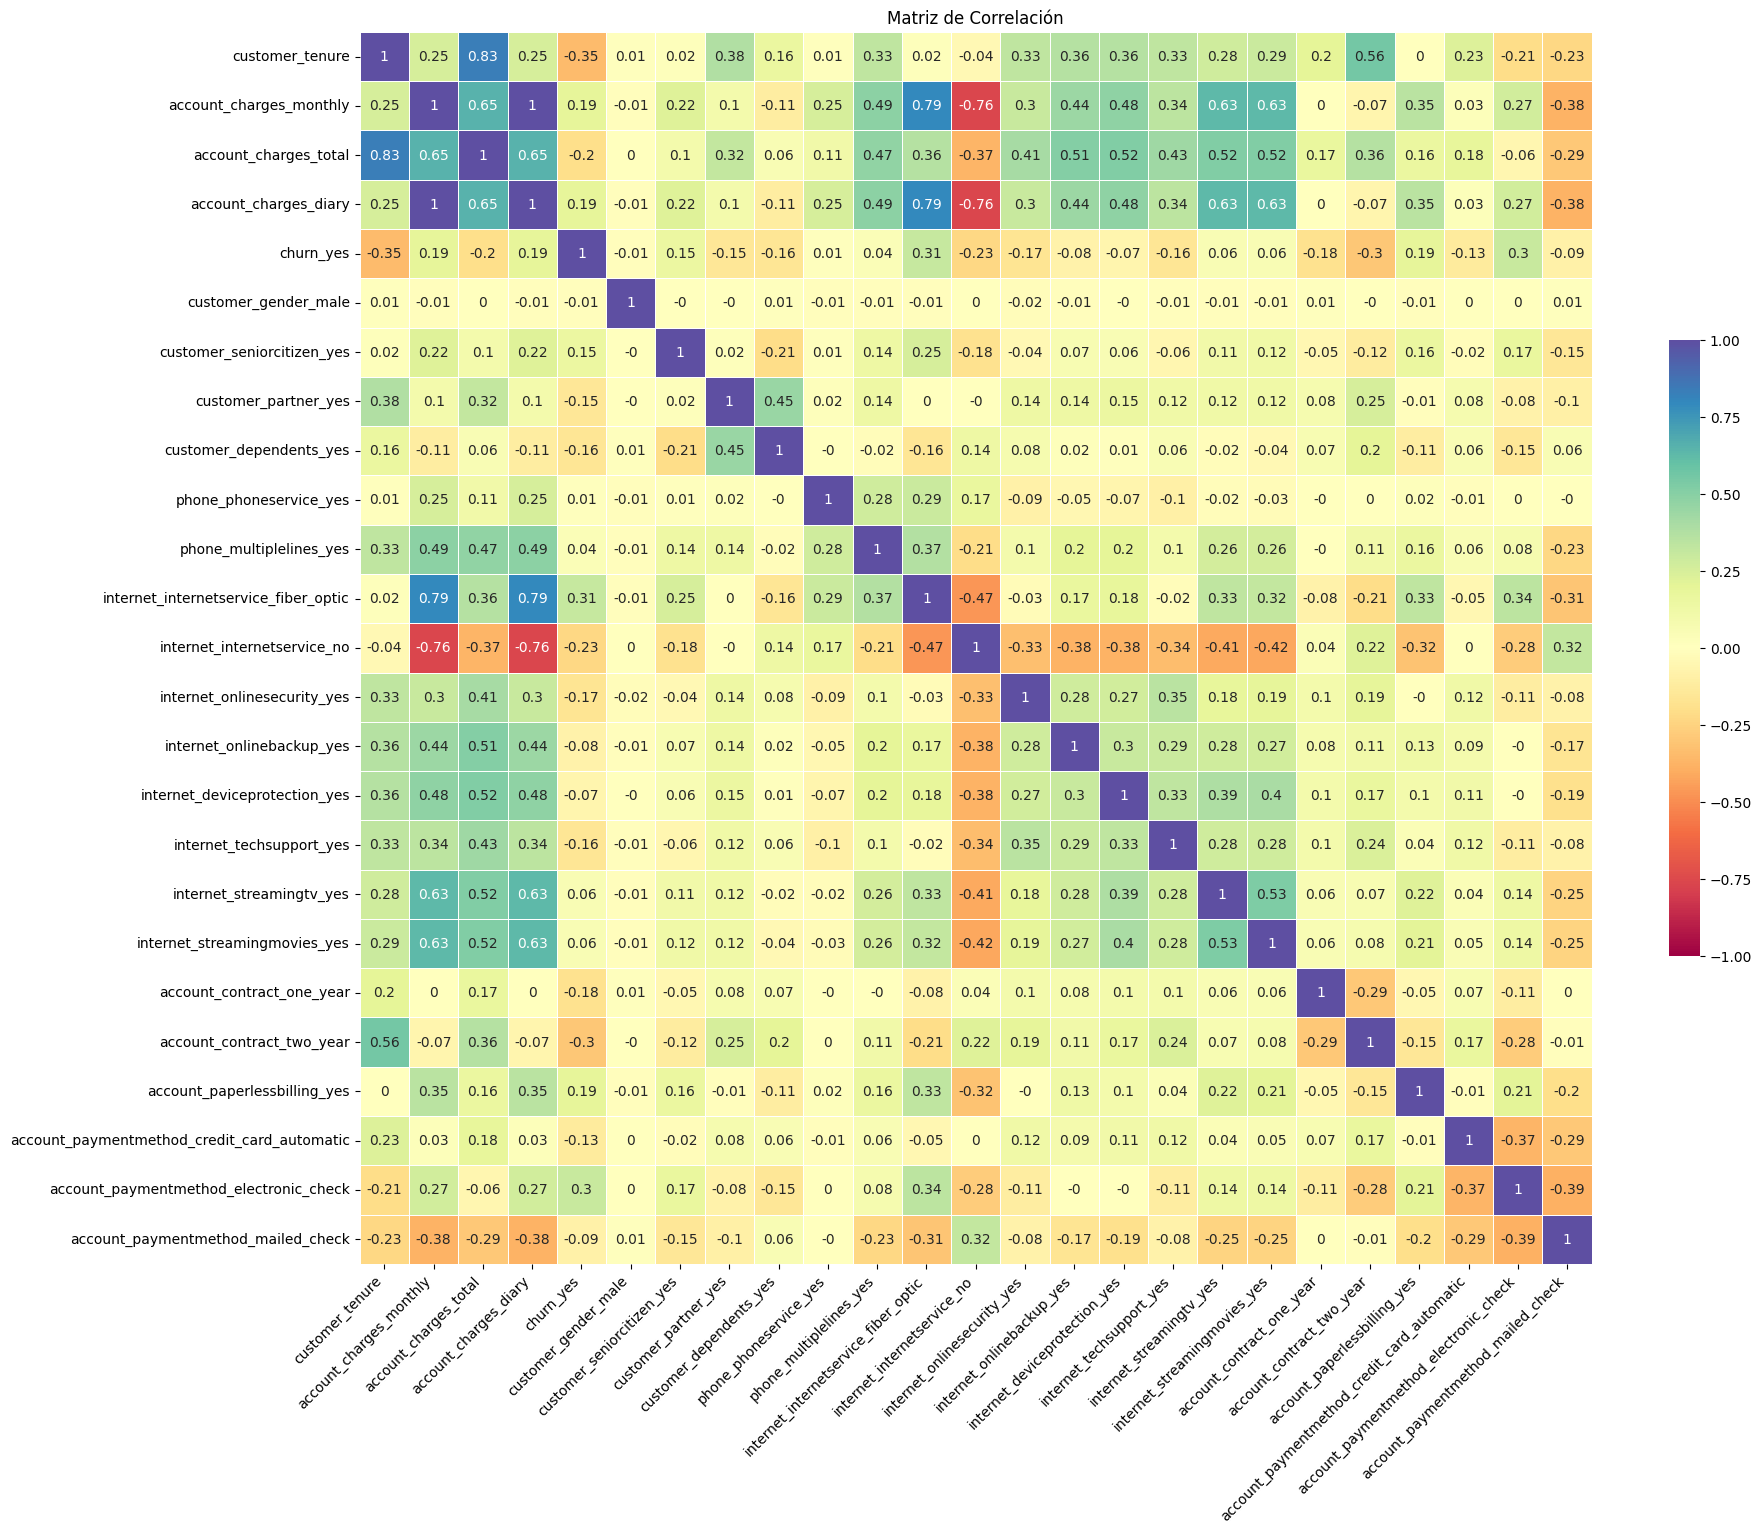

In [670]:
# Matriz de conrrelación.
fig, ax = plt.subplots(figsize=(20,16))

ax = sns.heatmap(np.round(correlacion, 2), vmax=1, vmin=-1, center=0,cmap='Spectral',
            square=True, linewidths=.5, annot=True, cbar_kws={"shrink": .5})
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, horizontalalignment='right')
ax.set_title('Matriz de Correlación')

plt.show()

### Correlación con las varibles relevantes.

In [671]:
# Variable objetivo.
target_var = 'churn_yes'

In [672]:
# Umbral minimo de correlación absoluta para la selecció.
limit = 0.2

In [673]:
# Filtración de varibles
variables_relevantes = correlacion.index[abs(correlacion[target_var]) >= limit].tolist()
variables_relevantes

['customer_tenure',
 'churn_yes',
 'internet_internetservice_fiber_optic',
 'internet_internetservice_no',
 'account_contract_two_year',
 'account_paymentmethod_electronic_check']

In [674]:
# Introducir la variable objetivo en caso de no encontrarse
if target_var not in variables_relevantes:
    variables_relevantes.append(target_var)

variables_relevantes

['customer_tenure',
 'churn_yes',
 'internet_internetservice_fiber_optic',
 'internet_internetservice_no',
 'account_contract_two_year',
 'account_paymentmethod_electronic_check']

In [675]:
# Matriz de correlacion con varibles relevantes.
corr_filtrada = correlacion.loc[variables_relevantes, variables_relevantes]
corr_filtrada

,customer_tenure,churn_yes,internet_internetservice_fiber_optic,internet_internetservice_no,account_contract_two_year,account_paymentmethod_electronic_check
customer_tenure,1.000000,-0.354049,0.017930,-0.037529,0.563801,-0.210197
churn_yes,-0.354049,1.000000,0.307463,-0.227578,-0.301552,0.301455
internet_internetservice_fiber_optic,0.017930,0.307463,1.000000,-0.465736,-0.209965,0.335763
internet_internetservice_no,-0.037529,-0.227578,-0.465736,1.000000,0.217542,-0.284608
account_contract_two_year,0.563801,-0.301552,-0.209965,0.217542,1.000000,-0.281147
account_paymentmethod_electronic_check,-0.210197,0.301455,0.335763,-0.284608,-0.281147,1.000000


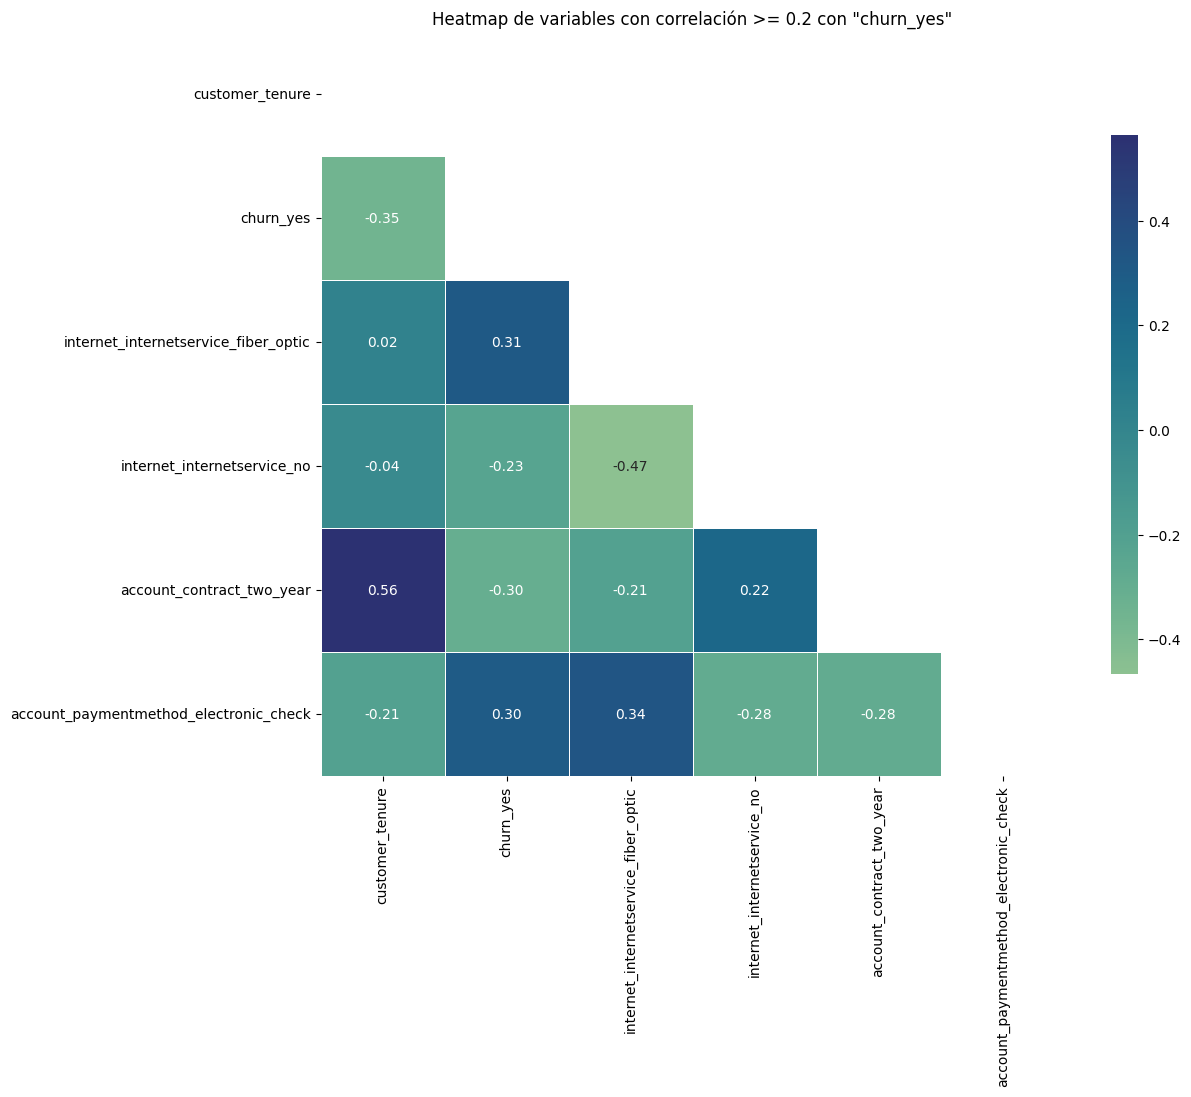

In [676]:
# Máscara para ocultar el triángulo superior de la matriz
mascara = np.triu(np.ones_like(corr_filtrada, dtype=bool))

# Grafica de la matriz
plt.figure(figsize=(12,10))
sns.heatmap(
    corr_filtrada,
    annot=True,
    fmt=".2f",
    cmap='crest',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.7},
    mask=mascara
)
plt.title(f'Heatmap de variables con correlación >= {limit} con "{target_var}"')
plt.show()

## Análisis Dirigido.

In [677]:
datos_enconding.columns

Index(['customer_tenure', 'account_charges_monthly', 'account_charges_total',
       'account_charges_diary', 'churn_yes', 'customer_gender_male',
       'customer_seniorcitizen_yes', 'customer_partner_yes',
       'customer_dependents_yes', 'phone_phoneservice_yes',
       'phone_multiplelines_yes', 'internet_internetservice_fiber_optic',
       'internet_internetservice_no', 'internet_onlinesecurity_yes',
       'internet_onlinebackup_yes', 'internet_deviceprotection_yes',
       'internet_techsupport_yes', 'internet_streamingtv_yes',
       'internet_streamingmovies_yes', 'account_contract_one_year',
       'account_contract_two_year', 'account_paperlessbilling_yes',
       'account_paymentmethod_credit_card_automatic',
       'account_paymentmethod_electronic_check',
       'account_paymentmethod_mailed_check'],
      dtype='object')

In [678]:
# Funcnion para grafica de relacion de variables numericas con la linea de ajuste
def grafica_relacion_numericas (data, columna_x, columna_y):
  fig = px.scatter(data, x=columna_x, y=columna_y, color='churn_yes',
                   color_discrete_map={False :'red', True: 'Green'},
                   title=f'Relación entre {columna_x.replace("_"," ")} y {columna_y.replace("_"," ")}',
                   trendline='ols'
                   )
  fig.update_layout(title={'x':0.5, 'y':0.9, 'font':{'size': 20, 'family': 'sans-serif'}},
                    xaxis_title=columna_x.replace("_"," ").upper(),
                    yaxis_title=columna_y.replace("_"," ").upper(),
                    width = 900, height= 500)
  return fig

In [679]:
# Graficas de las varibles numericas y su relación
monthlyVSdiary = grafica_relacion_numericas(datos_enconding, 'account_charges_monthly', 'account_charges_diary')
monthlyVSdiary.show()

In [680]:
# Graficas de las varibles numericas y su relación
tenureVStotal = grafica_relacion_numericas(datos_enconding, 'customer_tenure', 'account_charges_total')
tenureVStotal.show()

In [681]:
totalVSmonthly = grafica_relacion_numericas(datos_enconding, 'account_charges_total', 'account_charges_monthly')
totalVSmonthly.show()

In [682]:
tenureVSmonthly = grafica_relacion_numericas(datos_enconding, 'customer_tenure', 'account_charges_monthly')
tenureVSmonthly.show()

In [683]:
# Relacion de las variables caracteristicas con churn
for columna in datos_enconding.columns:
  if columna not in np.append(columnas_numericas, 'churn_yes'):
    ax = grafica_relacion_numericas(datos_enconding.corr(), columna, 'churn_yes')
    ax.show()

In [684]:
# Relacion de las variables númericas con churn
for columna in columnas_numericas:
  ax = px.box(datos_enconding, y='churn_yes', x=columna, color='churn_yes',
            title=f'churn x {columna.replace("_"," ")}', color_discrete_map={ False : 'red', True : 'green' })

  ax.update_layout(title={'x':0.5, 'y':0.9, 'font':{'size': 20, 'family': 'sans-serif'}}, width= 900, height=500)
  ax.update_yaxes(title_text='CHURN')
  ax.update_xaxes(title_text=columna.replace("_"," ").upper())

  ax.show()

## Análisis de Multicolinealidad.

In [685]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

#### Variables para el VIF

In [686]:
#
X = datos_enconding.drop(columns=['churn_yes'])
X_const = add_constant(X)

In [687]:
# Conversion del tipo de columnas
X_const = X_const.astype(float)

In [688]:
# Calcular el VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

# Mostrar resultado
display(vif_data.sort_values(by='VIF', ascending=False))

/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning:

divide by zero encountered in scalar divide



,Feature,VIF
2,account_charges_monthly,inf
4,account_charges_diary,inf
11,internet_internetservice_fiber_optic,148.510456
12,internet_internetservice_no,104.222375
0,const,73.262152
9,phone_phoneservice_yes,34.895470
18,internet_streamingmovies_yes,24.156974
17,internet_streamingtv_yes,24.081396
3,account_charges_total,10.811976
1,customer_tenure,7.584594


#### Analisis del VIF

| Rango de VIF       | Interpretación                |
| ------------------ | ----------------------------- |
| VIF ≈ 1            | Sin multicolinealidad         |
| 1 < VIF < 5        | Baja (aceptable)              |
| 5 ≤ VIF < 10       | Moderada (vigilar)            |
| VIF ≥ 10           | Alta (¡atención!)             |
| VIF = ∞ (infinito) | Multicolinealidad perfecta ⚠️ |

In [689]:
# VIF ALTA
columnas_vif_alta = vif_data[vif_data['VIF'] >= 10]['Feature'].tolist()
columnas_vif_alta

['const',
 'account_charges_monthly',
 'account_charges_total',
 'account_charges_diary',
 'phone_phoneservice_yes',
 'internet_internetservice_fiber_optic',
 'internet_internetservice_no',
 'internet_streamingtv_yes',
 'internet_streamingmovies_yes']

In [690]:
# VIF MODERADA
columnas_vif_moderada = vif_data[(vif_data['VIF'] >= 5) & (vif_data['VIF'] < 10)]['Feature'].tolist()
columnas_vif_moderada

['customer_tenure',
 'phone_multiplelines_yes',
 'internet_onlinesecurity_yes',
 'internet_onlinebackup_yes',
 'internet_deviceprotection_yes',
 'internet_techsupport_yes']

In [691]:
# VIF BAJA
columnas_vif_baja = vif_data[(vif_data['VIF'] >= 1) & (vif_data['VIF'] < 5)]['Feature'].tolist()
columnas_vif_baja

['customer_gender_male',
 'customer_seniorcitizen_yes',
 'customer_partner_yes',
 'customer_dependents_yes',
 'account_contract_one_year',
 'account_contract_two_year',
 'account_paperlessbilling_yes',
 'account_paymentmethod_credit_card_automatic',
 'account_paymentmethod_electronic_check',
 'account_paymentmethod_mailed_check']

#### Eliminación de columnas con VIF alta

####Opción de filtracion


In [692]:
columas_to_drop = ['account_charges_diary', 'internet_internetservice_no','phone_phoneservice_yes']

In [693]:
# Copy por seguridad.
X_const_filtro = X_const.copy()
X_const_filtro.drop(columns=columas_to_drop, inplace=True)

X_const_filtro = X_const_filtro.astype(float)

In [694]:
# Recalcular el VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_const_filtro.columns
vif_data["VIF"] = [variance_inflation_factor(X_const_filtro.values, i) for i in range(X_const_filtro.shape[1])]

# Rresultados
display(vif_data.sort_values(by="VIF", ascending=False))

,Feature,VIF
0,const,18.649055
2,account_charges_monthly,18.168780
3,account_charges_total,10.706800
1,customer_tenure,7.548716
9,internet_internetservice_fiber_optic,6.997820
17,account_contract_two_year,2.532131
14,internet_streamingtv_yes,2.188547
15,internet_streamingmovies_yes,2.187888
20,account_paymentmethod_electronic_check,1.967305
21,account_paymentmethod_mailed_check,1.847752


In [695]:
columnas_drop = ['account_charges_total']

In [696]:
# Copy por seguridad.
X_filtro_final = X_const_filtro.copy()
X_filtro_final.drop(columns=columnas_drop, inplace=True)

X_filtro_final = X_filtro_final.astype(float)

In [697]:
# Recalcular el VIF
vif_data_final = pd.DataFrame()
vif_data_final["Feature"] = X_filtro_final.columns
vif_data_final["VIF"] = [variance_inflation_factor(X_filtro_final.values, i) for i in range(X_filtro_final.shape[1])]

# Resultados ordenados
display(vif_data_final.sort_values(by="VIF", ascending=False))

,Feature,VIF
2,account_charges_monthly,17.283226
0,const,14.674312
8,internet_internetservice_fiber_optic,6.936112
1,customer_tenure,2.826197
16,account_contract_two_year,2.521228
13,internet_streamingtv_yes,2.166619
14,internet_streamingmovies_yes,2.163842
19,account_paymentmethod_electronic_check,1.964004
20,account_paymentmethod_mailed_check,1.825717
12,internet_techsupport_yes,1.712098


## Separación de Datos

In [698]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [699]:
# Separar features y target
X = datos_enconding.drop('churn_yes', axis=1)
y = datos_enconding['churn_yes']

In [700]:
# Dividir entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24, stratify=y)

In [701]:
# Normalización de modelo.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [702]:
# Balanceo con SMOTE
smote = SMOTE(random_state=24)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

## Revision con statmodels

In [703]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

In [704]:
X_train_con_constante=sm.add_constant(X_train[['customer_tenure','account_charges_monthly','account_charges_total']])

X_train_con_constante.head()

,const,customer_tenure,account_charges_monthly,account_charges_total
3202,1.0,0.070423,0.866169,0.060743
2314,1.0,0.380282,0.323881,0.157858
706,1.0,0.338028,0.363184,0.143959
1440,1.0,0.084507,0.657711,0.068180
6702,1.0,0.887324,0.813930,0.719525


In [705]:
modelo_statsmodels = sm.OLS(y_train,X_train_con_constante,hasconst=True).fit()
print(modelo_statsmodels.summary())

                            OLS Regression Results                            
Dep. Variable:              churn_yes   R-squared:                       0.225
Model:                            OLS   Adj. R-squared:                  0.224
Method:                 Least Squares   F-statistic:                     542.8
Date:                Tue, 19 Aug 2025   Prob (F-statistic):          8.27e-310
Time:                        08:51:39   Log-Likelihood:                -2670.3
No. Observations:                5625   AIC:                             5349.
Df Residuals:                    5621   BIC:                             5375.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

## Creación de Modelos

In [706]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

#### Regresión Logistica.

In [707]:
# Instanciar y entrenar
lr = LogisticRegression(random_state=24)
lr.fit(X_train_bal, y_train_bal)

# Predicciones
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

#### Random Forest

In [708]:
# Instanciar y entrenar
rf = RandomForestClassifier(random_state=24, max_depth=30)
rf.fit(X_train_bal, y_train_bal)

# Predicciones
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

## Evaluación de Modelos

In [709]:
from sklearn.metrics import ConfusionMatrixDisplay

***************** Regresión Logística *****************
-------------------------------------------------------
       Exactitud: 0.7583511016346838
       ROC AUC:   0.8480814925635837
_______________________________________________________
*************** Reporte de Clasificación **************
-------------------------------------------------------
              precision    recall  f1-score   support

       False       0.91      0.74      0.82      1033
        True       0.53      0.80      0.64       374

    accuracy                           0.76      1407
   macro avg       0.72      0.77      0.73      1407
weighted avg       0.81      0.76      0.77      1407

_______________________________________________________
***************** Matriz de Confusión *****************
 [[766 267]
 [ 73 301]]



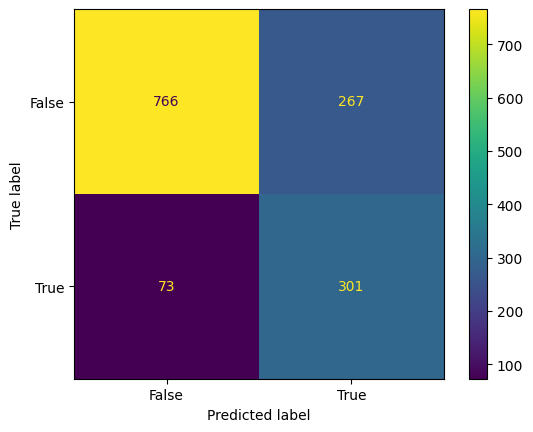

In [710]:
# Evaluación
print(f'{"*"*17} Regresión Logística {"*"*17}\n{"-"*55}')
print(f'{" "*7}Exactitud: {accuracy_score(y_test, y_pred_lr)}')
print(f'{" "*7}ROC AUC:   {roc_auc_score(y_test, y_prob_lr)}')
print(f'{"_"*55}\n{"*"*15} Reporte de Clasificación {"*"*14}\n{"-"*55}\n{classification_report(y_test, y_pred_lr)}')
print(f'{"_"*55}\n{"*"*17} Matriz de Confusión {"*"*17}\n {confusion_matrix(y_test, y_pred_lr)}\n')

visualizacion = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_lr), display_labels=lr.classes_)
visualizacion.plot();

******************** Random Forest ********************
-------------------------------------------------------
       Exactitud: 0.7739872068230277
       ROC AUC:   0.819158931723706
_______________________________________________________
*************** Reporte de Clasificación **************
-------------------------------------------------------
              precision    recall  f1-score   support

       False       0.85      0.84      0.85      1033
        True       0.57      0.58      0.58       374

    accuracy                           0.77      1407
   macro avg       0.71      0.71      0.71      1407
weighted avg       0.77      0.77      0.77      1407

_______________________________________________________
***************** Matriz de Confusión *****************
 [[872 161]
 [157 217]]



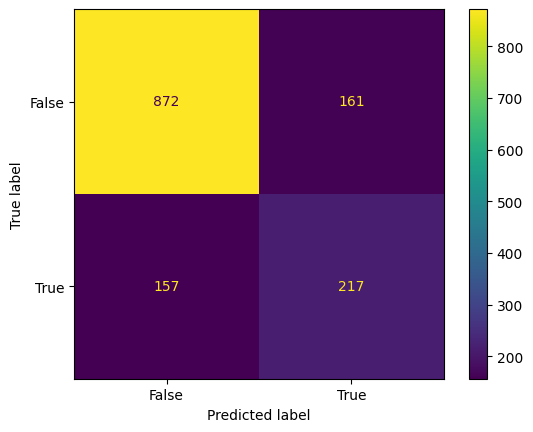

In [711]:
# Evaluación Random Forest
print(f'{"*"*20} Random Forest {"*"*20}\n{"-"*55}')
print(f'{" "*7}Exactitud: {accuracy_score(y_test, y_pred_rf)}')
print(f'{" "*7}ROC AUC:   {roc_auc_score(y_test, y_prob_rf)}')
print(f'{"_"*55}\n{"*"*15} Reporte de Clasificación {"*"*14}\n{"-"*55}\n{classification_report(y_test, y_pred_rf)}')
print(f'{"_"*55}\n{"*"*17} Matriz de Confusión {"*"*17}\n {confusion_matrix(y_test, y_pred_rf)}\n')

visualizacion = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_rf), display_labels=rf.classes_)
visualizacion.plot();

## Análisis de la variables importantes

In [712]:
# Features Importances de Random Forest
importances = rf.feature_importances_
rf_feature_importances = pd.DataFrame({'Features':X.columns,'Importances':(importances*100).round(2)}).sort_values('Importances',ascending=False)
rf_feature_importances

,Features,Importances
0,customer_tenure,15.59
2,account_charges_total,12.80
1,account_charges_monthly,10.84
3,account_charges_diary,10.59
19,account_contract_two_year,6.27
22,account_paymentmethod_electronic_check,5.17
10,internet_internetservice_fiber_optic,3.97
20,account_paperlessbilling_yes,3.59
18,account_contract_one_year,3.48
12,internet_onlinesecurity_yes,2.89


In [713]:
# Features Importances de Random Forest
lr_feature_importances = pd.DataFrame((lr.coef_*100).round(2),columns=X.columns, index=['Importances']).T.sort_values('Importances',ascending=False)
lr_feature_importances

,Importances
account_charges_total,100.74
internet_internetservice_fiber_optic,45.24
account_paymentmethod_electronic_check,18.39
phone_multiplelines_yes,18.25
internet_streamingtv_yes,17.20
account_paperlessbilling_yes,15.65
internet_streamingmovies_yes,11.09
customer_seniorcitizen_yes,5.68
internet_deviceprotection_yes,1.57
customer_gender_male,1.38


#Informe

Se construyeron dos modelos de predicción (Random Forest y Regresión Logística) con una exactitud de 0.76–0.77. Dado que el interés principal es identificar los factores de cancelación, se priorizó la precisión en clientes que no cancelan, donde la regresión logística obtuvo mejor desempeño (0.91 frente a 0.85).

El análisis de variables mostró como factores clave de cancelación:

Variables numéricas: antigüedad del cliente (customer_tenure), cargos mensuales y cargos totales.

Tipo de contrato: los contratos de mayor duración (1 o 2 años) presentan más cancelaciones.

Servicios de internet: ausencia de internet, falta de fibra óptica y baja en uso de streaming (TV y películas).

Recomendaciones:

Evaluar la posibilidad de ofrecer precios más accesibles.

Favorecer contratos a corto plazo para reducir la evasión.

Impulsar el uso de fibra óptica y mejorar los servicios de streaming.